# Curva ROC

# 1. Librerías

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import os

print("Carpeta actual:")
print(os.getcwd())
print("Archivos disponibles:")
print(os.listdir())
mypath = r"C:\Users\Eve\OneDrive\Desktop\Logística y Regularización"

Carpeta actual:
c:\Users\Eve\OneDrive\Desktop\Logística y Regularización
Archivos disponibles:
['CurvaROC.ipynb', 'LearningCurves.ipynb', 'Loga.ipynb', 'Máquina de Vector Soporte R.IPYNB', 'pima-indians-diabetes.csv', 'Regularización R.ipynb', 'RLogistica.ipynb', 'RNN R.ipynb']


In [19]:
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
mypath = "pima-indians-diabetes.csv"
data = pd.read_csv(mypath, sep=",", header=None, names=columns) #, header='infer')
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Y = data[['Outcome']]

In [21]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=0.7, random_state=7)
print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


In [22]:
modelo_LR = LogisticRegression()

modelo_LR.fit(Xtrain, ytrain)

c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
pred_bin = modelo_LR.predict(Xtest)
# ytest : etiquetas reales
# pred_bin : predicciones de mi modelo
cm = confusion_matrix(ytest, pred_bin)    # los renglones son los reales y las columnas las predicciones.
print(cm)

[[127  20]
 [ 38  46]]


In [24]:
pred = modelo_LR.predict_proba(Xtest)    # predicciones en formato probabilístico.
pred[0:5,:]  # la suma de los valores por renglón es 1. P.ej., un valor arriba de 0.5 es de la clase de esa coordenada
             # por lo que con solo una columna podemos seguir trabajando ya que son complementarias. 
             # En particular seleccionaremos más adelante la segunda columna y trabajaremos con ella:

array([[0.89084411, 0.10915589],
       [0.15810309, 0.84189691],
       [0.22212347, 0.77787653],
       [0.81073781, 0.18926219],
       [0.59979245, 0.40020755]])

In [25]:
my0s = (ytest['Outcome']==0)   # Se genera el vector Booleano, my0s, con TRUE para las entradas con 0s y FALSE para los 1s. Buscamos quedarnos solo con los negativos.
my1s = (ytest['Outcome']==1)   # De manera complemtaria, ahora "my1s" es el vector Booleanco con TRUE para los 1s - FALSE para los 0s. Ahora buscamos solo los positivos.
print(my0s.shape)
print(sum(my0s))   # ambos suman el total del Test set.
print(sum(my1s))

(231,)
147
84


In [27]:
# pred : tamaño (231,2) con las probabilidades compelemtarias por renglón.
# Así, al seleccionar solo la segunda columna, queda automáticamente que cuando dicho valor es menor a 0.5, la podemos
# asociar ahora a la clase negativa y cuando sea mayor al 0.5 será de la clase positiva
pred0s  = pred[my0s][:,1]    # seleccionamos las probabilidades de nuestro modelo solo para los casos de etiquetas de 0s reales.
                             # Es decir, en teoría todos estos debieran ser probabilidades de predicción menores a 0.5.
pred1s  = pred[my1s][:,1]    # seleccionamos las probabilidades de nuestro modelo solo para los casos de etiquetas de 1s reales.
                             # Es decir, en teoría todos estos debieran ser predicciones de valores mayores a 0.5.
print(pred0s.shape)   
print(pred1s.shape)

(147,)
(84,)


In [28]:
r0 = np.random.uniform(-0.3,0.3, size=pred0s.shape[0])    # Generamos aleatorios uniforme para el eje x

                                                          # de longitud el total de 0-TRUEs en Xtest, entre

                                                          # algún intervalo deseado, que aquí usamos (-0.3, +0.3)

r1 = np.random.uniform(0.7,1.3, size=pred1s.shape[0])     # El análogo para 1-TRUEs de Xtest. Pero para que aparezcan

                                                          # cercanos uno al otro, seleccionemos ahora el intervalo (+0.7, +1.3)

print(r0.shape)

#print(r0[0:5])

print(r1.shape)

#print(r1[0:5])


(147,)
(84,)


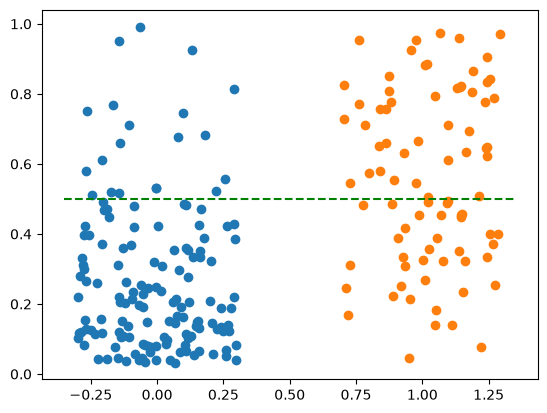

In [ ]:
# En el gráfico los puntos azules son las predicciones de todos los registros negativos reales.
# Es decir, para un modelo perfecto, todos los puntos azules deberían haber quedado abajo de 0.5.
# La columna de los puntos anaranjados son todas las predicciones de los registros positivos reales.
# Es decir, en teoría todos estos puntos debieron haber quedado arriba del 0.5.

plt.scatter(x=r0, y=pred0s)   # En teoría todos estos debieran ser menores a 0.5.
plt.scatter(x=r1, y=pred1s)   # Y todos estos debieran ser mayores a 0.5.
plt.hlines(0.5, -0.35, 1.35, color='g', linestyles='dashed')   # el primer valor es la constante para "y" y los otros 2 son 
                                                               # donde inicia y termina en el eje horizontal.

plt.show()

Hallazgos:
La gráfica te permite ver qué tan bien la regresión logística separa las dos clases usando el umbral de 0.5.
La interpretación principal es esta:
Puntos azules = casos realmente negativos (y = 0). Idealmente deberían tener una probabilidad predicha menor que 0.5.
Puntos naranjas = casos realmente positivos (y = 1). Idealmente deberían tener una probabilidad predicha mayor que 0.5.
Línea verde en 0.5 = umbral de clasificación.

Matriz de Confusión con %

In [ ]:
# Cuando hacemos nuestras predicciones y obtenemos por ejemplo la matriz de confusión,
# de manera predeterminada se está considerando que 0.5 es el umbral para las clases negativa y positiva.
pred_bin = modelo_LR.predict(Xtest)
cm = confusion_matrix(ytest, pred_bin)    # los renglones son los reales y las columnas las predicciones.
print(cm)
tt = np.sum(cm)
print('real-0: [%.3f, %.3f]' % (cm[0,0]/tt, cm[0,1]/tt))
print('real-1: [%.3f, %.3f]' % (cm[1,0]/tt, cm[1,1]/tt))

[[127  20]
 [ 38  46]]
real-0: [0.550, 0.087]
real-1: [0.165, 0.199]


Hallazgos


Recalls

In [ ]:
TPrate = cm[1,1]/(cm[1,0]+cm[1,1])
FPrate = cm[0,1]/(cm[0,0]+cm[0,1])
print('TP_rate-recall:%.5f' % TPrate)           # TP/ (TP+FN) = RECALL
print('FP_rate:%.5f' % FPrate)                  # TP / (TP + FP) = FPR

TP_rate-recall:0.54762
FP_rate:0.13605


Gráfico

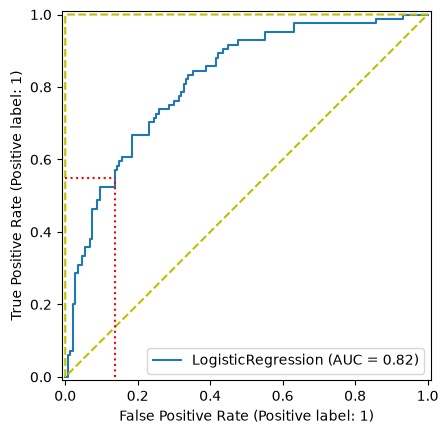

In [33]:
RocCurveDisplay.from_estimator(modelo_LR, Xtest, ytest)
plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.hlines(TPrate, 0, FPrate, colors='r', linestyles='dotted')  # Se calcula TPrate y FPrate con base a threshold=0.5
plt.vlines(FPrate, 0, TPrate, colors='r', linestyles='dotted')  # Pero el mejor umbral para que ambos errores estén lo más equilibrados
plt.show()

Hallazgos:
Área bajo la curva: Esta es una curva ROC y sirve para evaluar qué tan bien tu modelo de regresión logística distingue entre la clase 0 y la clase 1 considerando todos los posibles umbrales de clasificación, no únicamente 0.5.
AUC = 0.83 Existe aproximadamente un 83 % de probabilidad de que el modelo prediga correctamente.

Ajustar un mejor treshold 

In [ ]:
# regresa los TP para un umbral deseado:
def fun_thTPrate(th, modelo, x, y):   
  p = modelo.predict_proba(x)   # shape (231x2)
  my1s = (y['Outcome']==1) 
  pred1s  = p[my1s][:,1]
  return sum(pred1s > th) / sum(my1s)

In [35]:
fun_thTPrate(0.5, modelo_LR, Xtest, ytest)  # validando nuestra función con th=0.5

np.float64(0.5476190476190477)

un %59 calculo los verdaderos positivos correctamente.

In [ ]:
# Análogo ahora con los FP:

def fun_thFPrate(th, modelo, x, y):   
  p = modelo.predict_proba(x)
  my0s = (y['Outcome']==0) 
  pred0s  = p[my0s][:,1]
  return sum(pred0s>th) / sum(my0s)

In [37]:
fun_thFPrate(0.5, modelo_LR, Xtest, ytest)   # validando nuestra función con th=0.5

np.float64(0.1360544217687075)

Treshold 0.3

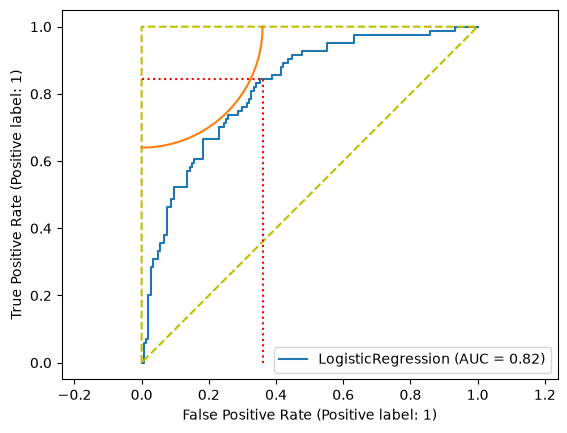

In [38]:
# En este gráfico trata de modificar los valores del umbral deseado "new_th" 
# y el valor del radio "rr", de manera que el círculo quede tangente a la ROC-curve 
# y el nodo del rectángulo naranja coincidan, aproximadamente. 
# Si ambos errores, FP y FN son igual de costosos, esta coincidencia del nodo y 
# el círculo equilibra "aproximadamente" ambos errores a su mínimo conjunto.

new_th = 0.3 # búsquda del mejor umbral que minimiza el total FP+FN.
rr = 0.36   # búsqueda del mejor radio
new_TPrate = fun_thTPrate(new_th, modelo_LR, Xtest, ytest)
new_FPrate = fun_thFPrate(new_th, modelo_LR, Xtest, ytest)
RocCurveDisplay.from_estimator(modelo_LR, Xtest, ytest)
plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.hlines(new_TPrate, 0, new_FPrate, colors='r', linestyles='dotted')  
plt.vlines(new_FPrate, 0, new_TPrate, colors='r', linestyles='dotted')  

# graficando el pedazo de cícrulo:
an = np.linspace(1.5*np.pi, 2*np.pi, 20)
plt.plot(rr*np.cos(an), rr*np.sin(an)+1)
plt.axis('equal')
plt.show()

Hallazgos:
AUC = 0.83 
Existe aproximadamente un 83 % de probabilidad de que el modelo prediga correctamente los falsos positivos. 
Al disminuir el treshold, hay mayor cantidad de erroes que el modelo deja pasar. 

Mátrix de Confusion

In [42]:
pred_pr = modelo_LR.predict_proba(Xtest)  # obtenemos primero las predicciones en formato probabilístico de 0 a 1. Este es vector 2D.
pred_pr = pred_pr[:,1]    # como comentamos, es suficiente quedarnos con las probabilidades de la segunda coordenada. Este ya es vector 1D.
# Y realizamos nuestras predicciones a la clase 0 y a la clase 1 con base al mejor umbral new_th encontrado:
pred_bin_newTh = pred_pr > new_th
pred_bin_05 = modelo_LR.predict(Xtest)
print('Casos donde FP y FN los consideramos igualmente costosos:\n')
print('Predicciones con el umbral predeterminado 0.5:')
cm05 = confusion_matrix(ytest, pred_bin_05)    # los renglones son los reales y las columnas las predicciones.
print(cm05)
print('\nPredicciones con un mejor umbral de %.2f:' % new_th)
cmTh = confusion_matrix(ytest, pred_bin_newTh)    
print(cmTh)

Casos donde FP y FN los consideramos igualmente costosos:

Predicciones con el umbral predeterminado 0.5:
[[127  20]
 [ 38  46]]

Predicciones con un mejor umbral de 0.30:
[[94 53]
 [13 71]]


Comparar Modelos con AUC

In [43]:
modelo_SVM = SVC().fit(Xtrain, np.ravel(ytrain))
modelo_SVM.score(Xtest,ytest)

0.7532467532467533

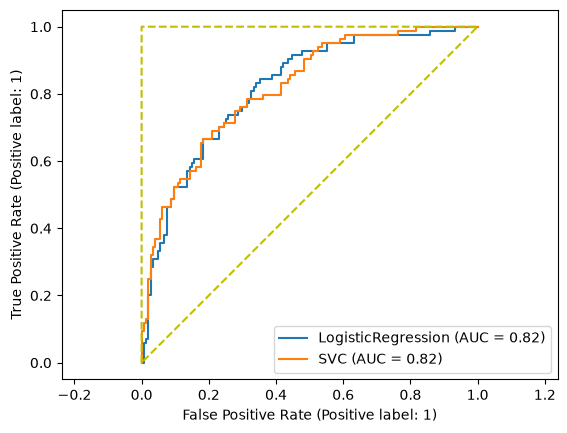

In [44]:
lr_curve = RocCurveDisplay.from_estimator(modelo_LR, Xtest, ytest)
svm_curve = RocCurveDisplay.from_estimator(modelo_SVM, Xtest, ytest, ax=lr_curve.ax_)
plt.plot([0,0,1,0],[0,1,1,0], 'y--')



plt.axis('equal')

plt.show()

Hallazgos: Por un % muy pequeño el MRL sigue siendo el mejor. 
